In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps
  
def impute_with_median(data, rt_raw):
    median_rt = np.nanmedian(rt_raw)
    rt_imputed = rt_raw.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

# Data

In [4]:
# Modeling setup:
# emissions : 3 components -> reaction time, response angle, response error

# inputs for them:
# reaction time: error, prev_rt | attention, coherence, expectiation | bias
# response angle: stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# response error: rt, prev_err | attention, coherence, expectation | bias

# models for them:
# reaction time: Gamma GLM
# response angle: von Mises GLM
# response error: Gamma GLM

In [5]:
rdf = r_table.copy()

# 1) Compute previous-trial target, response, reaction time & error
rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)
rdf['prev_rt']     = rdf.groupby(['subj', 'sess', 'run'])['f_resp'].shift(1)
rdf['prev_error']  = rdf.groupby(['subj', 'sess', 'run'])['resp_err'].shift(1)
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])
rdf['prev_rt']     = rdf['prev_rt'].fillna(rdf['f_resp'])
rdf['prev_error']  = rdf['prev_error'].fillna(rdf['resp_err'])

# 2) Reshape metadata into (n_trials, T, 1)
n_trials = rdf.shape[0] // 120
T = 120
reshape = lambda x: x.values.reshape(n_trials, T, 1).astype(np.float32)

baseline_bias    = np.ones((n_trials, T, 1), dtype=np.float32)
attention        = (rdf['att'] == "focused").astype(np.float32)
coherence        = (rdf['coh'] == "high").astype(np.float32)
expectation      = (rdf['exp_al'] == "expected").astype(np.float32)

attention   = reshape(attention)
coherence   = reshape(coherence)
expectation = reshape(expectation)

# 3) Error predictor for RT: signed error in radians
# resp_err = np.deg2rad(rdf['resp_err'])
# resp_err = reshape(resp_err)

# 4) Stimuli and history for RA
stim       = np.deg2rad(rdf['t_calib'])
prev_stim  = np.deg2rad(rdf['prev_target'])
prev_resp  = np.deg2rad(rdf['prev_resp'])

# wrap to [-pi, pi]
wrap = lambda x: ((x + np.pi) % (2*np.pi)) - np.pi
stim      = wrap(reshape(stim))
prev_stim = wrap(reshape(prev_stim))
prev_resp = wrap(reshape(prev_resp))

# 4b) Previous reaction time and error
prev_rt_raw = (rdf['prev_rt'].values - 250).reshape(n_trials, T, 1) * (1000/120)
prev_reaction_time = impute_with_lin_interpolation(prev_rt_raw)

prev_err_raw = rdf['prev_error'].values.reshape(n_trials, T, 1)
prev_err_neg_mask = rdf['prev_error'].values.reshape(n_trials, T, 1) < 0
prev_err_raw[prev_err_neg_mask] = prev_err_raw[prev_err_neg_mask] * -1
prev_response_error = prev_err_raw

# 5) Reaction time (ms)
rt_raw = (rdf['f_resp'].values - 250).reshape(n_trials, T, 1) * (1000/120)
# reaction_time = np.clip(rt_raw, 0.01, None).astype(np.float32)
reaction_time = impute_with_lin_interpolation(rt_raw)

# 6) Response angle in radians, wrapped
response_angle = np.deg2rad(rdf['resp']).values
response_angle = wrap(response_angle.reshape(n_trials, T, 1))

# 7) Response error for emissions (positive)
err_raw = rdf['resp_err'].values.reshape(n_trials, T, 1)
err_neg_mask = rdf['v_err'].values.reshape(n_trials, T, 1) < 0
err_raw[err_neg_mask] = err_raw[err_neg_mask] * -1
response_error = err_raw
abs_response_error = np.abs(response_error)

# 8) Build feature blocks
# RT features: [1, Error, Prev_RT, Att, Coh, Exp]
x_rt = np.concatenate([
    baseline_bias,
    response_error, prev_reaction_time,
    attention, coherence, expectation,
    # response_error * attention,
    # response_error * coherence,
    # response_error * expectation
], axis=-1)

# RA features: [1, stim, prev_stim, prev_resp, Att, Coh, Exp]
x_ra = np.concatenate([
    baseline_bias,
    stim, prev_stim, prev_resp,
    attention, coherence, expectation
], axis=-1)

# RE features: [1, RT, Prev_Error, Att, Coh, Exp]
x_re = np.concatenate([
    baseline_bias,
    reaction_time, prev_response_error,
    attention, coherence, expectation,
    # reaction_time * attention,
    # reaction_time * coherence,
    # reaction_time * expectation
], axis=-1)

x_rt = jnp.array(x_rt)
x_ra = jnp.array(x_ra)
x_re = jnp.array(x_re)

y_rt = jnp.array(reaction_time)
y_ra = jnp.array(response_angle)
y_re = jnp.array(response_error)

# Verify shapes
print("inputs shape:", (x_rt.shape,x_ra.shape,x_re.shape) )
print("emissions shape:", (y_rt.shape,y_ra.shape,y_re.shape) )


inputs shape: ((288, 120, 6), (288, 120, 7), (288, 120, 6))
emissions shape: ((288, 120, 1), (288, 120, 1), (288, 120, 1))


In [6]:
# print and check if any of these have nan in them
print("coherence", np.isnan(coherence).sum())
print("attention", np.isnan(attention).sum())
print("expectation", np.isnan(expectation).sum())

# print("resp_err", np.isnan(resp_err).sum())

print("stim", np.isnan(stim).sum())
print("prev_stim", np.isnan(prev_stim).sum())
print("prev_resp", np.isnan(prev_resp).sum())

print("reaction_time", np.isnan(reaction_time).sum())
print("prev_reaction_time", np.isnan(prev_reaction_time).sum())
print("response_angle", np.isnan(response_angle).sum())
print("response_error", np.isnan(response_error).sum())
print("prev_response_error", np.isnan(prev_response_error).sum())

coherence 0
attention 0
expectation 0
stim 0
prev_stim 0
prev_resp 0
reaction_time 0
prev_reaction_time 0
response_angle 0
response_error 0
prev_response_error 0


Text(0.5, 1.0, 'Response Error')

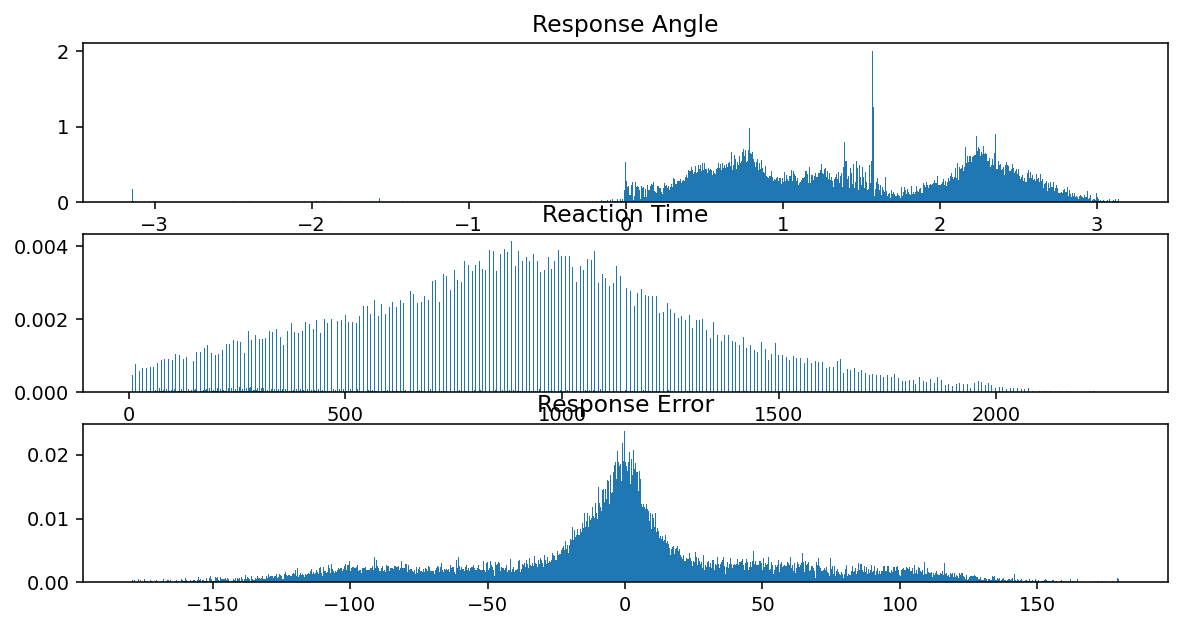

In [7]:
fix, axs = plt.subplots(3, 1, figsize=(10, 5))
axs[0].hist(response_angle.flatten(), bins=1000, density=True)
axs[0].set_title("Response Angle")
axs[1].hist(reaction_time.flatten(), bins=1000, density=True)
axs[1].set_title("Reaction Time")
axs[2].hist(response_error.flatten(), bins=1000, density=True)
axs[2].set_title("Response Error")

# Trainings

In [8]:
to_train = ((x_rt, y_rt), (x_ra, y_ra), (x_re, y_re))
bmodels = (BlockHMMrt, BlockHMMra, BlockHMMre)
onemodels = (BlockOneRT, BlockOneRA, BlockOneRE)

dirs = (
    './caches/rt',
    './caches/ra',
    './caches/re'
)

chosen_states = ( 2, 2, 2)

In [9]:
for i in range(0,3):
    inputs, emissions = to_train[i]
    input_dim = inputs.shape[-1]
    emission_dim = emissions.shape[-1]
    
    # --- One state model training ---
    print(f"Training one state model for {dirs[i]}...")
    
    # One state model cross-validation
    # One state model does not need global since there is no state switching
    one_crossval_results = {}
    for idx, (s_em, s_in) in tqdm(enumerate(zip(emissions.reshape(12, 4 * 6, 120, emission_dim), inputs.reshape(12, 4 * 6, 120, input_dim))), total=12):
        one_crossval_results[idx] = {}
        shuffle_idx = np.random.permutation(len(s_em))
        one_ll_mean, one_ll = cross_validate_regressor(model=onemodels[i](), emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=5000, inputs=s_in[shuffle_idx], init="default")
        one_crossval_results[idx][1] = one_ll

    with open(f'{dirs[i]+"/one_crossval_results.pkl"}', 'wb') as f:
        pickle.dump(one_crossval_results, f)
    
    # --- Global model training ---
    print(f"Training global model for {dirs[i]}...")
    global_params = {}
    losses = []
    for nstate in tqdm(range(2, 10)):
        model = bmodels[i](nstate, input_dim, emission_dim)
        parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
        subset_idx = np.random.choice(np.arange(0, len(emissions)), len(emissions), replace=False)
        fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions[subset_idx], inputs = inputs[subset_idx], num_iters = 500, verbose = False)
        global_params[nstate] = fit_params
        losses.append(lps)
    
    with open(f'{dirs[i]+"/global_params.pkl"}', 'wb') as f:
        pickle.dump(global_params, f)
    
    # --- Cross-validation of subject models uing global initialization ---
    print(f"Cross-validating subject models for {dirs[i]}...")
    crossval_results = {}
    for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 120, emission_dim), inputs.reshape(12, 4 * 6, 120, input_dim))):
        crossval_results[idx] = {}
        shuffle_idx = np.random.permutation(len(s_em))
        for nstate in tqdm(range(2, 10), desc=f'sub-{idx+1}'):
            model = bmodels[i](nstate, input_dim, emission_dim)
            gpar = global_params[nstate]
            parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                      method="pretrained",
                                                      initial_probs=gpar.initial.probs,
                                                      transition_matrix=gpar.transitions.transition_matrix,
                                                      w1 = gpar.emissions.w1,
                                                      w2 = gpar.emissions.w2)
            ll_mean, ll = cross_validate_regressor(model=model, emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=500, inputs=s_in[shuffle_idx], init = (parameters, properties))
            crossval_results[idx][nstate] = ll
    with open(f'{dirs[i]+"/sub_crossval_results.pkl"}', 'wb') as f:
        pickle.dump(crossval_results, f)

Training one state model for ./caches/rt...


100%|██████████| 12/12 [00:23<00:00,  1.99s/it]



Training global model for ./caches/rt...


 50%|█████     | 4/8 [00:24<00:24,  6.10s/it]E0724 09:28:53.448306   13534 hlo_lexer.cc:443] Failed to parse int literal: 554909908499626281254
E0724 09:28:53.626202   13534 hlo_lexer.cc:443] Failed to parse int literal: 215766023842092697283172
E0724 09:28:53.448306   13534 hlo_lexer.cc:443] Failed to parse int literal: 554909908499626281254
E0724 09:28:53.626202   13534 hlo_lexer.cc:443] Failed to parse int literal: 215766023842092697283172
100%|██████████| 8/8 [00:49<00:00,  6.13s/it]


Cross-validating subject models for ./caches/rt...


...

100%|██████████| 12/12 [00:27<00:00,  2.29s/it]


Training global model for ./caches/re...


100%|██████████| 8/8 [00:35<00:00,  4.46s/it]


Cross-validating subject models for ./caches/re...


sub-12: 100%|██████████| 8/8 [00:36<00:00,  4.58s/it]


In [10]:
for i in range(0,3):
    
    # lod global parameters
    with open(f'{dirs[i]+"/global_params.pkl"}', 'rb') as f:
        global_params = pickle.load(f)
    
    # after deciding on the optimal number of states, we can train subject-specific models
    nstate = chosen_states[i]
    inputs, emissions = to_train[i]
    input_dim = inputs.shape[-1]
    emission_dim = emissions.shape[-1]
    
    subject_params = {}
    # --- Subject-specific model training ---
    print(f"Training subject-specific models for {dirs[i]}...")

    for idx, (s_em, s_in) in tqdm(enumerate(zip(emissions.reshape(12, 4 * 6, 120, emission_dim), inputs.reshape(12, 4 * 6, 120, input_dim))), total=12):
        subject_params[idx] = {}
        shuffle_idx = np.random.permutation(len(s_em))
        
        model = bmodels[i](nstate, input_dim, emission_dim)
        gpar = global_params[nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                    method="pretrained",
                                                    initial_probs=gpar.initial.probs,
                                                    transition_matrix=gpar.transitions.transition_matrix,
                                                    w1 = gpar.emissions.w1,
                                                    w2 = gpar.emissions.w2,)
        fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 500, verbose = False)
        subject_params[idx][nstate] = fit_params

    with open(f'{dirs[i]+"/sub_params.pkl"}', 'wb') as f:
        pickle.dump(subject_params, f)
        
    # --- Most likely states for subject-specific models ---
    print(f"Computing most likely states for subject-specific models for {dirs[i]}...")
    
    ml_states = {}
    cem = emissions.reshape(12, 4 * 6, 120, emission_dim)
    cin = inputs.reshape(12, 4 * 6, 120, input_dim)
    for idx in tqdm(range(12), desc=f''):
        em = jnp.array(cem[idx].reshape(-1, 120, emission_dim))
        inps = jnp.array(cin[idx].reshape(-1, 120, input_dim))
        
        model = bmodels[i](nstate, input_dim, emission_dim)
        
        gpar = subject_params[idx][nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                    method="pretrained",
                                                    initial_probs=gpar.initial.probs,
                                                    transition_matrix=gpar.transitions.transition_matrix,
                                                    w1 = gpar.emissions.w1,
                                                    w2 = gpar.emissions.w2,)
        most_likely_states_vmap = vmap(lambda trial, inp: model.most_likely_states(parameters, trial, inp))
        t_trail = most_likely_states_vmap(em, inps)
        ml_states[idx] = t_trail
        
    with open(f'{dirs[i]+"/ml_states.pkl"}', 'wb') as f:
        pickle.dump(ml_states, f)
        
        
    # --- Postierior hmm smoothed probabilities for subject-specific models ---
    print(f"Computing posterior probabilities for subject-specific models for {dirs[i]}...")
    
    smoothed_states = {}
    cem = emissions.reshape(12, 4 * 6, 120, emission_dim)
    cin = inputs.reshape(12, 4 * 6, 120, input_dim)
    for idx in tqdm(range(12), desc=f''):
        em = jnp.array(cem[idx].reshape(-1, 120, emission_dim))
        inps = jnp.array(cin[idx].reshape(-1, 120, input_dim))
        
        model = bmodels[i](nstate, input_dim, emission_dim)
        
        gpar = subject_params[idx][nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                    method="pretrained",
                                                    initial_probs=gpar.initial.probs,
                                                    transition_matrix=gpar.transitions.transition_matrix,
                                                    w1 = gpar.emissions.w1,
                                                    w2 = gpar.emissions.w2,)
        most_likely_states_vmap = vmap(lambda trial, inp: model.smoother(parameters, trial, inp))
        t_trail = most_likely_states_vmap(em, inps)
        smoothed_states[idx] = t_trail
        
    with open(f'{dirs[i]+"/smoothed_states.pkl"}', 'wb') as f:
        pickle.dump(smoothed_states, f)

Training subject-specific models for ./caches/rt...


100%|██████████| 12/12 [00:35<00:00,  2.95s/it]


Computing most likely states for subject-specific models for ./caches/rt...


100%|██████████| 12/12 [00:00<00:00, 15.88it/s]


Computing posterior probabilities for subject-specific models for ./caches/rt...


...

100%|██████████| 12/12 [00:41<00:00,  3.42s/it]


Computing most likely states for subject-specific models for ./caches/re...


100%|██████████| 12/12 [00:00<00:00, 56.17it/s]


Computing posterior probabilities for subject-specific models for ./caches/re...


100%|██████████| 12/12 [00:00<00:00, 69.05it/s]


# Specially for the response error model

In [11]:
# for i in range(2,3):

#     nstate = chosen_states[i]
#     inputs, emissions = to_train[i]
#     input_dim = inputs.shape[-1]
#     emission_dim = emissions.shape[-1]

#     subject_params = {}
#     # --- Subject-specific model training ---
#     print(f"Training subject-specific models for {dirs[i]}...")

#     for idx, (s_em, s_in) in tqdm(enumerate(zip(y_re.reshape(12, 4 * 6, 120, emission_dim), x_re.reshape(12, 4 * 6, 120, input_dim))), total=12):
#         subject_params[idx] = {}
#         shuffle_idx = np.random.permutation(len(s_em))
        
#         model = onemodels[i]()
#         parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior")
#         fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 5000, verbose = False)
#         subject_params[idx][nstate] = fit_params
    
#     with open(f'{dirs[i]+"/sub_params.pkl"}', 'wb') as f:
#         pickle.dump(subject_params, f)